# 01 — Data Cleaning & Preprocessing

**Goal:** Load the raw Netflix CSV, understand its structure, handle missing values, and engineer useful features.

---

## What we'll do
1. Load the raw CSV
2. Inspect shape, dtypes, null counts
3. Handle missing values
4. Parse dates and extract temporal features
5. Parse `duration` into a numeric value
6. Export clean DataFrame for use in subsequent notebooks

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_cleaner import load_data, clean_data, get_clean_df

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load raw data

In [2]:
df_raw = load_data()
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Loaded 8,807 rows × 12 columns
Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [3]:
# Data types
df_raw.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [4]:
# Missing value analysis
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(1)
pd.DataFrame({'missing': missing, 'pct': missing_pct})[missing > 0]

,missing,pct
director,2634,29.9
country,831,9.4
cast,825,9.4
date_added,10,0.1
rating,4,0.0
duration,3,0.0


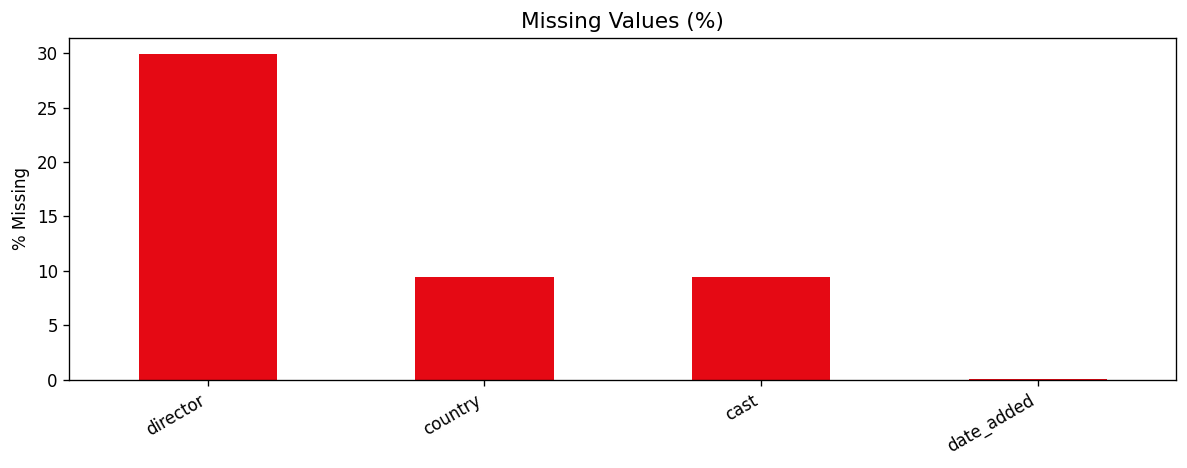

In [5]:
# Visualise missing data
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct[missing_pct > 0].plot(kind='bar', ax=ax, color='#E50914', edgecolor='none')
ax.set_title('Missing Values (%)', fontsize=13)
ax.set_ylabel('% Missing')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 2. Clean data

In [6]:
df = clean_data(df_raw)
df.head(3)

Dropped 0 duplicate rows
Cleaning complete ✅
type                object
year_added           Int64
duration_numeric     int64
primary_genre       object


/Users/vaishnavipujala/Desktop/netflix-eda/src/data_cleaner.py:76: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["date_added"].fillna("January 1, 2000", inplace=True)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,year_added,month_added,month_name,day_of_week,duration_numeric,listed_in_clean,primary_genre,primary_country,content_age
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,...,"As her father nears the end of his life, filmm...",2021,9,Sep,Saturday,90,Documentaries,Documentaries,United States,1
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,"After crossing paths at a party, a Cape Town t...",2021,9,Sep,Friday,2,"International TV Shows, TV Dramas, TV Mysteries",International TV Shows,South Africa,0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,...,To protect his family from a powerful drug lor...,2021,9,Sep,Friday,1,"Crime TV Shows, International TV Shows, TV Act...",Crime TV Shows,Unknown,0


In [7]:
# Verify new columns
print('New columns added:')
new_cols = ['year_added', 'month_added', 'month_name', 'day_of_week',
            'duration_numeric', 'primary_genre', 'primary_country', 'content_age']
df[new_cols].head(5)

New columns added:


,year_added,month_added,month_name,day_of_week,duration_numeric,primary_genre,primary_country,content_age
0,2021,9,Sep,Saturday,90,Documentaries,United States,1
1,2021,9,Sep,Friday,2,International TV Shows,South Africa,0
2,2021,9,Sep,Friday,1,Crime TV Shows,Unknown,0
3,2021,9,Sep,Friday,1,Docuseries,Unknown,0
4,2021,9,Sep,Friday,2,International TV Shows,India,0


In [8]:
# Duration analysis
print('Movies — duration_numeric stats:')
print(df[df['type']=='Movie']['duration_numeric'].describe().round(1))
print('\nTV Shows — duration_numeric (seasons) stats:')
print(df[df['type']=='TV Show']['duration_numeric'].describe().round(1))

Movies — duration_numeric stats:
count    6131.0
mean       99.5
std        28.4
min         0.0
25%        87.0
50%        98.0
75%       114.0
max       312.0
Name: duration_numeric, dtype: float64

TV Shows — duration_numeric (seasons) stats:
count    2676.0
mean        1.8
std         1.6
min         1.0
25%         1.0
50%         1.0
75%         2.0
max        17.0
Name: duration_numeric, dtype: float64


## 3. Summary statistics

In [9]:
print('Content type distribution:')
print(df['type'].value_counts())
print('\nTop 10 countries:')
print(df['primary_country'].value_counts().head(10))
print('\nTop 10 genres:')
print(df['primary_genre'].value_counts().head(10))
print('\nTop ratings:')
print(df['rating'].value_counts().head(8))

Content type distribution:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Top 10 countries:
primary_country
United States     3211
India             1008
Unknown            831
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Name: count, dtype: int64

Top 10 genres:
primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       774
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     388
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64

Top ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
Name: count, dtype: int64


In [10]:
# Save clean data
df.to_pickle('../data/netflix_clean.pkl')
print('Saved to data/netflix_clean.pkl')

Saved to data/netflix_clean.pkl
